In [ ]:
import pandas as pd 


# Flight Delay Prediction Model

This notebook is an exploratory application of machine learning using Python. It focuses on feature engineering, training and evaluating a Random Forest classifier, and understanding how flight schedule and weather variables contribute to delay risk.

The project is designed primarily to develop practical classification-modelling skills. Features, modelling decisions, and interpretations are refined throughout the analysis based on evaluation results and lessons learned. The final model is intended for exploratory analysis rather than operational forecasting as the dataset is a subset of 20 airports limited to 4 months. 

## Load & Inspect the Modeling Dataset

The merged flight and weather dataset is loaded into pandas and checked for its size, columns, data types, missing values, and delayed values.

In [ ]:
# Load merged dataset
df = pd.read_csv(r'C:\Users\what1\OneDrive\Documents\Flight Delay Prediction Model\data\cleaned_merged\merged_flight_weather.csv')

In [26]:
#define function for quick data health-check

def check_dataframe (df):
    print("DATASET INFO:")
    df.info()

    print("\nSUMMARY STATISTICS:")
    display(df.describe(include="all").T)

    print("\nMISSING VALUES:")
    display(df.isnull().sum().to_frame("missing count"))

    print("\nDUPLICATE COUNT:")
    print(df.duplicated().sum())

    print("\nPREVIEW DATAFRAME:")
    display(df.head())

check_dataframe(df)   


DATASET INFO:
<class 'pandas.DataFrame'>
RangeIndex: 1141948 entries, 0 to 1141947
Data columns (total 19 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   FLIGHT_DATE         1141948 non-null  str    
 1   MONTH               1141948 non-null  int64  
 2   DAY_OF_MONTH        1141948 non-null  int64  
 3   DAY_OF_WEEK         1141948 non-null  int64  
 4   ORIGIN              1141948 non-null  str    
 5   DESTINATION         1141948 non-null  str    
 6   ROUTE               1141948 non-null  str    
 7   AIRLINE             1141948 non-null  str    
 8   SCHEDULED_DEP_TIME  1141948 non-null  int64  
 9   DEPARTURE_HOUR      1141948 non-null  int64  
 10  DISTANCE            1141948 non-null  float64
 11  IS_DELAYED          1141948 non-null  int64  
 12  WEATHER_DATE        1141948 non-null  str    
 13  AIRPORT             1141948 non-null  str    
 14  TEMPERATURE         1141948 non-null  float64
 15  VISIBILITY  

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
FLIGHT_DATE,1141948,120,2025-03-27,10535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MONTH,1141948.0,NaN,NaN,NaN,2.551934,1.11946,1.0,2.0,3.0,4.0,4.0
DAY_OF_MONTH,1141948.0,NaN,NaN,NaN,15.630729,8.688727,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,1141948.0,NaN,NaN,NaN,3.984744,1.999683,1.0,2.0,4.0,6.0,7.0
ORIGIN,1141948,20,DEN,98423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DESTINATION,1141948,304,ORD,35051,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ROUTE,1141948,2113,LGA-ORD,3658,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AIRLINE,1141948,14,DL,207431,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCHEDULED_DEP_TIME,1141948.0,NaN,NaN,NaN,1382.453778,494.035903,1.0,947.0,1355.0,1815.0,2359.0
DEPARTURE_HOUR,1141948.0,NaN,NaN,NaN,13.545652,4.907614,0.0,9.0,13.0,18.0,23.0



MISSING VALUES:


,missing count
FLIGHT_DATE,0
MONTH,0
DAY_OF_MONTH,0
DAY_OF_WEEK,0
ORIGIN,0
DESTINATION,0
ROUTE,0
AIRLINE,0
SCHEDULED_DEP_TIME,0
DEPARTURE_HOUR,0



DUPLICATE COUNT:
354

PREVIEW DATAFRAME:


,FLIGHT_DATE,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,ORIGIN,DESTINATION,ROUTE,AIRLINE,SCHEDULED_DEP_TIME,DEPARTURE_HOUR,DISTANCE,IS_DELAYED,WEATHER_DATE,AIRPORT,TEMPERATURE,VISIBILITY,WINDSPEED,PRECIPITATION,WEATHER_FLAGS
0,2025-01-01,1,1,3,SFO,JFK,SFO-JFK,AA,1030,10,2586.0,0,2025-01-01,SFO,49.8,10.0,4.4,0.00,0
1,2025-01-01,1,1,3,BOS,LAX,BOS-LAX,AA,801,8,2611.0,0,2025-01-01,BOS,44.4,6.9,8.7,0.46,10000
2,2025-01-01,1,1,3,LAX,JFK,LAX-JFK,AA,1130,11,2475.0,0,2025-01-01,LAX,53.3,3.6,4.7,0.00,100000
3,2025-01-01,1,1,3,PHX,OMA,PHX-OMA,AA,2025,20,1037.0,0,2025-01-01,PHX,58.0,8.5,2.8,0.00,0
4,2025-01-01,1,1,3,PHX,SMF,PHX-SMF,AA,1104,11,647.0,1,2025-01-01,PHX,58.0,8.5,2.8,0.00,0


Data-check Observations:
- The final dataset contains 354 identical rows across the retained columns. These rows were not removed because true duplicates had already been checked using aircraft tail numbers before the identifier was excluded. They may represent separate flights with the same model features.
- `FLIGHT_DATE` & `WEATHER_DATE` will be converted to datetime as it got imported as a string.
- `WEATHER_FLAGS` will be restored to 06-digit text to preserve their original format. 
- All other columns in dataset satisfactory with no missing values.

In [32]:
#convert date columns to datetime type

df["FLIGHT_DATE"]= pd.to_datetime(df["FLIGHT_DATE"])
df["WEATHER_DATE"]= pd.to_datetime(df["WEATHER_DATE"]) 

#restore weather flags to 06 digit text by converting to str & adding zeros to left
df["WEATHER_FLAGS"]= df["WEATHER_FLAGS"].astype(str).str.zfill(6) 

#preview corrections
display(df.head())
print(df.dtypes)

,FLIGHT_DATE,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,ORIGIN,DESTINATION,ROUTE,AIRLINE,SCHEDULED_DEP_TIME,DEPARTURE_HOUR,DISTANCE,IS_DELAYED,WEATHER_DATE,AIRPORT,TEMPERATURE,VISIBILITY,WINDSPEED,PRECIPITATION,WEATHER_FLAGS
0,2025-01-01,1,1,3,SFO,JFK,SFO-JFK,AA,1030,10,2586.0,0,2025-01-01,SFO,49.8,10.0,4.4,0.00,000000
1,2025-01-01,1,1,3,BOS,LAX,BOS-LAX,AA,801,8,2611.0,0,2025-01-01,BOS,44.4,6.9,8.7,0.46,010000
2,2025-01-01,1,1,3,LAX,JFK,LAX-JFK,AA,1130,11,2475.0,0,2025-01-01,LAX,53.3,3.6,4.7,0.00,100000
3,2025-01-01,1,1,3,PHX,OMA,PHX-OMA,AA,2025,20,1037.0,0,2025-01-01,PHX,58.0,8.5,2.8,0.00,000000
4,2025-01-01,1,1,3,PHX,SMF,PHX-SMF,AA,1104,11,647.0,1,2025-01-01,PHX,58.0,8.5,2.8,0.00,000000


FLIGHT_DATE           datetime64[us]
MONTH                          int64
DAY_OF_MONTH                   int64
DAY_OF_WEEK                    int64
ORIGIN                           str
DESTINATION                      str
ROUTE                            str
AIRLINE                          str
SCHEDULED_DEP_TIME             int64
DEPARTURE_HOUR                 int64
DISTANCE                     float64
IS_DELAYED                     int64
WEATHER_DATE          datetime64[us]
AIRPORT                          str
TEMPERATURE                  float64
VISIBILITY                   float64
WINDSPEED                    float64
PRECIPITATION                float64
WEATHER_FLAGS                    str
dtype: object


In [33]:
#delayed vs. not delayed count
delay_summary= df["IS_DELAYED"].value_counts().to_frame("FLIGHT_COUNT")


#delayed vs. not delayed percentage 
delay_summary["PERCENT"]= (df["IS_DELAYED"].value_counts(normalize=True) * 100).round(2)

#map column names
delay_summary=delay_summary.rename(index={
    0: "Not delayed",
    1: "Delayed"
})

display(delay_summary)


,FLIGHT_COUNT,PERCENT
IS_DELAYED,,
Not delayed,905444,79.29
Delayed,236504,20.71


## Exploratory Data Analysis Charts

### Delayed vs. Not-delayed Bar Chart

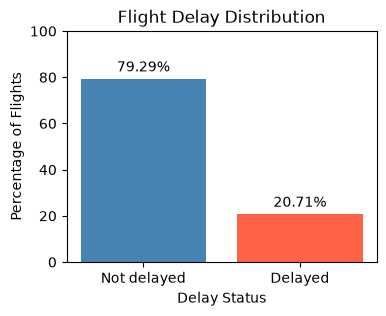

In [47]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(4,3))

#plot bar chart with percent of delays & its index as flights
bars= plt.bar(
    delay_summary.index,
    delay_summary["PERCENT"],
    color=["steelblue", "tomato"]
)

plt.title("Flight Delay Distribution")
plt.xlabel("Delay Status")
plt.ylabel("Percentage of Flights")

#add percentage labels on bars & adjust scale
plt.bar_label(
    bars,
    labels=[f"{value:.2f}%" for value in delay_summary["PERCENT"]],
    padding=3
)
plt.ylim(0,100)

plt.show()

### Target Class Distribution

Of the 1,141,948 flights, 79.29% were not delayed and 20.71% were delayed. Because the classes are imbalanced, a model predicting every flight as not delayed would already achieve 79.29% accuracy. Therefore, accuracy alone will not be enough to judge the model.

### Delay-rate by Departure Hour Line Chart

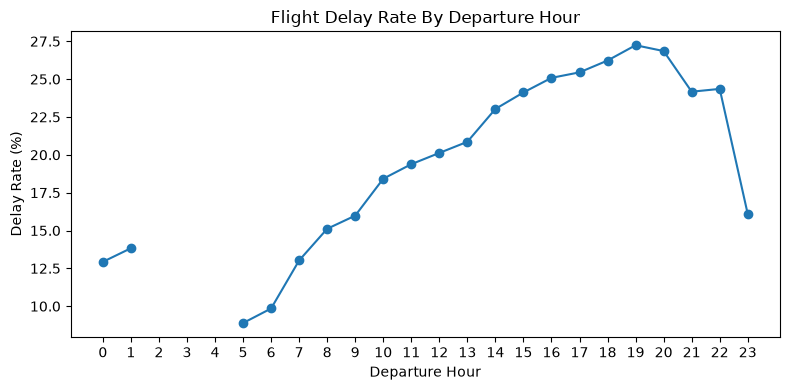

In [ ]:
#calculate delay rate for each departure hour (0 - 23) 

hourly_delayrate= (
    df.groupby ("DEPARTURE_HOUR")["IS_DELAYED"].mean().mul(100)
)
hourly_delayrate = hourly_delayrate.reindex(range(24)) #creating line break due to no flights from hour 1-5
#plot line chart 
plt.figure(figsize=(8,4))

plt.plot(
    hourly_delayrate.index,
    hourly_delayrate.values,
    marker="o" 
)
plt.title("Flight Delay Rate By Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Delay Rate (%)") 
plt.xticks(range(24)) 
plt.tight_layout()

plt.show() 


Delay rates generally increased throughout the day, reaching their highest level at around 19:00.  Morning flights had lower observed delay rates, suggesting that departure hour may be useful for prediction. Late-night results should be interpreted cautiously because fewer flights may operate during these hours.
- No flights were recorded between 02:00 and 04:59, so the line contains a gap for those hours.

### Dry vs. Precipitation Days Delay-Rate Bar Chart

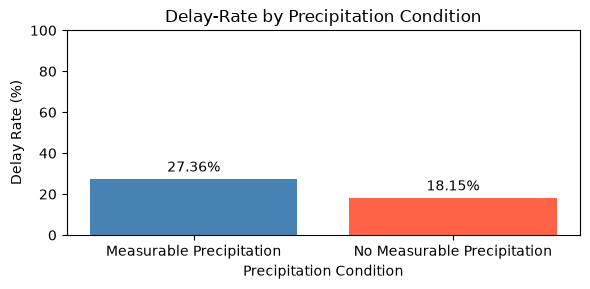

In [59]:
import numpy as np

#create precipitation map for dry vs. precipitation days classification
df["PRECIPITATION_GROUP"]= np.where(
    df["PRECIPITATION"] > 0, 
    "Measurable Precipitation", 
    "No Measurable Precipitation") 

#delay-rate for each precipitation group 
precipitation_delayrate=(
df.groupby("PRECIPITATION_GROUP")["IS_DELAYED"].mean().mul(100))


#create bar chart 
plt.figure(figsize=(6,3)) 

bars= plt.bar(
    precipitation_delayrate.index,
    precipitation_delayrate.values,
    color=["steelblue","tomato"]
)

plt.title("Delay-Rate by Precipitation Condition")
plt.xlabel("Precipitation Condition")
plt.ylabel("Delay Rate (%)") 
plt.bar_label(bars, fmt="{:.2f}%", padding=3) 
plt.ylim(0,100)
plt.tight_layout() 
plt.show() 

- Flights on days with measurable precipitation had a 27.36% delay rate, compared with 18.15% on days without measurable precipitation. This suggests precipitation may be a useful feature for delay prediction.



# Feature Engineering
- Model-ready feature for NOAA weather flags are translated into readable weather conditions before selecting the model inputs.
- The map for `weather_flags` is obtained through NOAA ReadMe.md for SOTD dataset.
- The target column `IS_DELAYED` was created during SQL cleaning from the existing BTS `ARR_DEL15` indicator.

In [61]:
#check weather flag values 
df["WEATHER_FLAGS"].value_counts().sort_index()

WEATHER_FLAGS
000000    740927
001000     65412
010000    185696
010010     52391
010110      2459
011000     34535
011010      1474
100000     21975
101000     11765
110000     16279
110010      1526
111000      5787
111010      1722
Name: count, dtype: int64

In [ ]:
#map weather flags into readable weather conditions 
weather_condition_map = {
    "000000": "No reported condition",
    "001000": "Snow or ice",
    "010000": "Rain",
    "010010": "Rain + Thunder",
    "010110": "Rain + Hail + Thunder",
    "011000": "Rain + Snow or ice",
    "011010": "Rain + Snow or ice + Thunder",
    "100000": "Fog",
    "101000": "Fog + Snow or ice",
    "110000": "Fog + Rain",
    "110010": "Fog + Rain + Thunder",
    "111000": "Fog + Rain + Snow or ice",
    "111010": "Fog + Rain + Snow or ice + Thunder"
}
#Create weather condition column for modelling with the map 
df["WEATHER_CONDITION"]= df["WEATHER_FLAGS"].map(weather_condition_map) 

#verify mapping by displaying unique values in column
display(
    df[["WEATHER_FLAGS","WEATHER_CONDITION"]]
    .drop_duplicates().sort_values("WEATHER_FLAGS")
    .reset_index(drop=True)
)

#confirm if every weather flag got mapped
print("Unmapped rows:", df["WEATHER_CONDITION"].isna().sum())

,WEATHER_FLAGS,WEATHER_CONDITION
0,000000,No reported condition
1,001000,Snow or ice
2,010000,Rain
3,010010,Rain + Thunder
4,010110,Rain + Hail + Thunder
5,011000,Rain + Snow or ice
6,011010,Rain + Snow or ice + Thunder
7,100000,Fog
8,101000,Fog + Snow or ice
9,110000,Fog + Rain


Unmapped rows: 0


# Predictor Modelling 

## 1. Prepare Model Data
- The selected input features (`X`) contain the flight information available to the model, while `IS_DELAYED` is the target (`y`) the model will learn to predict.


### Split the Data
- The data is split into 80% training and 20% testing. Stratification preserves the delayed and not-delayed proportions in both sets, allowing the model to be evaluated fairly on unseen data.

In [69]:
#select input columns that will be used by the model: 
feature_columns= [
    "AIRLINE",
    "ORIGIN",
    "DESTINATION",
    "DEPARTURE_HOUR",
    "WEATHER_CONDITION"
]

X= df[feature_columns].copy() 

#select output column the model will learn to predict:
y= df["IS_DELAYED"].copy() 

#display column shape & preview 
print("X shape:", X.shape)
print("Y shape:", y.shape) 
display(X.head())
display(y.head()) 


X shape: (1141948, 5)
Y shape: (1141948,)


,AIRLINE,ORIGIN,DESTINATION,DEPARTURE_HOUR,WEATHER_CONDITION
0,AA,SFO,JFK,10,No reported condition
1,AA,BOS,LAX,8,Rain
2,AA,LAX,JFK,11,Fog
3,AA,PHX,OMA,20,No reported condition
4,AA,PHX,SMF,11,No reported condition


0    0
1    0
2    0
3    0
4    1
Name: IS_DELAYED, dtype: int64

In [72]:
#Split the data into 80% training and 20% testing using stratification

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size= 0.20, 
    random_state=42, #produce same split each time 
    stratify=y #preserve balance 
)

print("X_train:", X_train.shape)
print("X_test:",X_test.shape) 
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (913558, 5)
X_test: (228390, 5)
y_train: (913558,)
y_test: (228390,)


- Result: 913,558 training flights and 228,390 testing flights after stratification. 

### Encode Categorical Features

- Airline, airport, and weather condition values are converted into numeric columns using one-hot encoding. The scheduled departure hour is already numeric and remains unchanged.

In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

#columns with categories 
categorical_features=[
    "AIRLINE",
    "ORIGIN",
    "DESTINATION",
    "WEATHER_CONDITION"
]

#column which is already numeric
numeric_features=[
    "DEPARTURE_HOUR"
]

#create preprocessing instructions 
preprocessor = ColumnTransformer(
    transformers=[
        ( "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features),

        ( "numeric",
            "passthrough",
            numeric_features)
    ])


## 2. Train the Model


###  Random Forest Classifier 
- Random Forest classifier is connected to the preprocessing pipeline. During training, categorical features are one-hot encoded and the model learns delay patterns from the training data.This is to give additonal importance to delayed flights which are far less common in the dataset. 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

#Create Random Forest 
random_forest= RandomForestClassifier( 
    n_estimators=100,   #build 100 decision trees 
    max_depth=20, #question level limit for each decision tree
    min_samples_leaf=10,   #10 flights per final tree group 
    class_weight="balanced",  #balance the model by giving importance to delayed flights
    random_state=42, 
    n_jobs=-1,) 

#Connect the preprocessing and modeling 
model= Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", random_forest)
    ]
)



### Fit the Model
- The pipeline learns the categories from the training data, performs one-hot encoding, & trains the Random Forest. 

In [75]:
#train preprocessing pipeline & Random Forest
model.fit(X_train, y_train)

print("Model training completed") 

Model training completed


### Predict Test Outcomes

The trained model predicts delayed or not-delayed outcomes for unseen test flights.

In [ ]:
# Predict delay outcomes on the test data

y_pred= model.predict(X_test) #giving trained model unseen test flights

#count how many predictions created & show first 10 predicitons 
print("Predictions created:",len(y_pred))
print("First 10 predictions:",y_pred[:10])


Predictions created: 228390
First 10 predictions: [0 0 1 1 0 1 0 1 1 0]


## 3. Evaluate the Model

The predicted outcomes will be compared with the actual outcomes using accuracy, precision, recall, F1-score, and a confusion matrix.

### Model Accuracy

Accuracy measures the percentage of test flights the model predicted correctly. It is compared with the majority class baseline to check whether the model performs better than always predicting **not delayed**.

In [78]:
from sklearn.metrics import accuracy_score


# Calculate the percentage of test predictions that match the real outcomes
model_accuracy= accuracy_score(y_test, y_pred)

# Calculate accuracy of predicting every flight as the most common class
baseline_accuracy= y_test.value_counts(normalize=True).max()

print(f"Model accuracy: {model_accuracy:.2%}")
print(f"Baseline accuracy: {baseline_accuracy:.2%}")

Model accuracy: 65.91%
Baseline accuracy: 79.29%



The model has lower overall accuracy than the baseline. However, the baseline achieves 79.29% by predicting every flight as **not delayed**, meaning it identifies no delayed flights. Since the model was class-balanced to detect delays, accuracy alone cannot determine its usefulness. Precision, recall, F1-score, and the confusion matrix must be checked next.

### Precision

Precision measures how often the model is correct when it predicts that a flight will be delayed.

In [79]:
from sklearn.metrics import precision_score 

#calculate precision for delayed flights, where IS_DELAYED=1 
delay_precision= precision_score(y_test, y_pred) 

#display precision as percentage 
print (f"Delayed flight precision: {delay_precision:.2%}") 


Delayed flight precision: 31.46%



The delayed-flight precision is 31.46% meaning that when the model predicts a delay, it is correct about 31 out of every 100 times. Although this is higher than the dataset's overall delay rate of 20.71%, the model still produces many false delay warnings. Recall must be checked next to see how many actual delays the model successfully detects.

### Recall

Recall measures how many of the flights that were actually delayed were successfully identified by the model.

In [80]:
from sklearn.metrics import recall_score 

#calculate percentage of actual delayed flights detected by model 
delay_recall= recall_score(y_test, y_pred) 

#display recall as percentage 
print (f"Delayed flight recall:{delay_recall:.2%}") 

Delayed flight recall:54.77%


The model finds more than half of the delays, but its 31.46% precision shows that many delay predictions are false warnings.

### F1-Score

The F1-score combines precision and recall into one result. It is only high when the model both detects delays and avoids too many false delay warnings.

In [81]:
from sklearn.metrics import f1_score  

#Combine delayed-flight precision and recall into one score
delay_f1 = f1_score(y_test, y_pred)

#Display the F1-score as a percentage
print(f"Delayed-flight F1-score: {delay_f1:.2%}")

Delayed-flight F1-score: 39.96%


the F1 score of 39.96% here reflects the model's moderate recall (54.77%) but low precision (31.46%). The model detects more than half of actual delays, but its delay predictions are often incorrect. The confusion matrix will show the exact numbers behind these results.

### Confusion Matrix

The confusion matrix shows the exact numbers of correct predictions, false delay warnings, and missed delays.


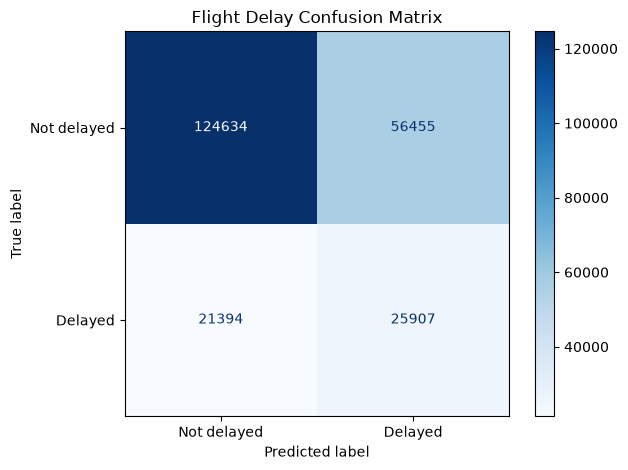

In [85]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # import matrix tools
import matplotlib.pyplot as plt

# Compare the actual outcomes with the model's predictions
confusion_results = confusion_matrix(y_test, y_pred)

# Create the confusion matrix chart
matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_results,
    display_labels=["Not delayed", "Delayed"]
)

# Display and format the chart
matrix_display.plot(cmap="Blues", values_format="d")
plt.title("Flight Delay Confusion Matrix")
plt.tight_layout()

plt.savefig(
    r"C:\Users\what1\OneDrive\Documents\Flight Delay Prediction Model\visuals\confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Confusion Matrix Results

- **124,634 true negatives:** correctly predicted as not delayed.
- **56,455 false positives:** predicted as delayed but were not delayed.
- **21,394 false negatives:** actually delayed but the model missed them.
- **25,907 true positives:** correctly predicted as delayed.

The model detected **25,907 of 47,301 actual delays**, explaining its 54.77% recall. However, it also produced **56,455 false delay warnings**, explaining its lower 31.46% precision. Therefore, the model identifies some delay risk but is not reliable enough for operational decisions.

## 4. Interpret the Baseline Model

### Baseline Feature Importance

Feature importance measures how much each input helped the Random Forest make its predictions. The importance values of one-hot encoded categories are combined back into their original columns.

In [86]:
# Get encoded feature names created by the preprocessing pipeline
encoded_feature_names = (
    model.named_steps["preprocessor"].get_feature_names_out()
)

# Get importance score assigned to every encoded feature
importance_scores = (
    model.named_steps["classifier"].feature_importances_
)

# Store encoded feature names and scores in dataframe
encoded_importance = pd.DataFrame({
    "ENCODED_FEATURE": encoded_feature_names,
    "IMPORTANCE": importance_scores
})

# Find which original column each encoded feature came from
def find_original_feature(encoded_name):
    for feature in categorical_features:
        if encoded_name.startswith(f"categorical__{feature}_"):
            return feature

    # Remove the pipeline prefix from the numeric feature
    return encoded_name.replace("numeric__", "")

# Add the original column name to each encoded feature
encoded_importance["ORIGINAL_FEATURE"] = (
    encoded_importance["ENCODED_FEATURE"].apply(find_original_feature)
)

# Add together the scores belonging to the same original column
baseline_feature_importance = (
    encoded_importance
    .groupby("ORIGINAL_FEATURE")["IMPORTANCE"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(baseline_feature_importance)

,ORIGINAL_FEATURE,IMPORTANCE
0,WEATHER_CONDITION,0.483629
1,DEPARTURE_HOUR,0.248664
2,ORIGIN,0.116577
3,AIRLINE,0.081377
4,DESTINATION,0.069753


#### Baseline Feature Importance Results

`WEATHER_CONDITION` had the highest importance at **48.36%**, followed by `DEPARTURE_HOUR` at **24.87%**. The model relied less on `ORIGIN` (11.66%), `AIRLINE` (8.14%), and `DESTINATION` (6.98%).

This means weather condition and scheduled departure hour influenced the model most. 

#### Baseline Model Conclusion

The baseline model detected 54.77% of actual delays but produced many false warnings, resulting in 31.46% precision and 65.91% accuracy. It found some predictive signal, particularly from weather condition and departure hour, but the five inputs were insufficient for reliable flight-level prediction. An expanded model will now test whether additional valid features improve performance.

## 5. Build the Expanded Model

The expanded model adds calendar, distance, and numerical weather information while continuing to exclude leakage columns.

In [87]:
# Select the input columns for the expanded model
expanded_feature_columns = [
    "AIRLINE",
    "ORIGIN",
    "DESTINATION",
    "DEPARTURE_HOUR",
    "MONTH",
    "DAY_OF_WEEK",
    "DISTANCE",
    "TEMPERATURE",
    "VISIBILITY",
    "WINDSPEED",
    "PRECIPITATION",
    "WEATHER_CONDITION"
]

# Create X containing the expanded model inputs
X_expanded = df[expanded_feature_columns].copy()

# Create y containing the result the model must predict
y_expanded = df["IS_DELAYED"].copy()

# Confirm the number of rows and input columns
print("Expanded X shape:", X_expanded.shape)
print("Expanded y shape:", y_expanded.shape)

# Preview the expanded input data
display(X_expanded.head())

Expanded X shape: (1141948, 12)
Expanded y shape: (1141948,)


,AIRLINE,ORIGIN,DESTINATION,DEPARTURE_HOUR,MONTH,DAY_OF_WEEK,DISTANCE,TEMPERATURE,VISIBILITY,WINDSPEED,PRECIPITATION,WEATHER_CONDITION
0,AA,SFO,JFK,10,1,3,2586.0,49.8,10.0,4.4,0.00,No reported condition
1,AA,BOS,LAX,8,1,3,2611.0,44.4,6.9,8.7,0.46,Rain
2,AA,LAX,JFK,11,1,3,2475.0,53.3,3.6,4.7,0.00,Fog
3,AA,PHX,OMA,20,1,3,1037.0,58.0,8.5,2.8,0.00,No reported condition
4,AA,PHX,SMF,11,1,3,647.0,58.0,8.5,2.8,0.00,No reported condition


### Reuse the Same Training and Test Rows

The expanded model uses the same training and testing flights as the baseline model. This creates a fair comparison because both models are evaluated on identical test data.

In [88]:
#Select same training rows used by the baseline model
X_train_expanded = X_expanded.loc[X_train.index].copy()
y_train_expanded = y_expanded.loc[y_train.index].copy()

#Select  same testing rows used by the baseline model
X_test_expanded = X_expanded.loc[X_test.index].copy()
y_test_expanded = y_expanded.loc[y_test.index].copy()

#Confirm the expanded training and testing sizes
print("X_train_expanded:", X_train_expanded.shape)
print("X_test_expanded:", X_test_expanded.shape)
print("y_train_expanded:", y_train_expanded.shape)
print("y_test_expanded:", y_test_expanded.shape)

X_train_expanded: (913558, 12)
X_test_expanded: (228390, 12)
y_train_expanded: (913558,)
y_test_expanded: (228390,)


### Preprocess the Expanded Features

Categorical columns are converted into one-hot encoded numbers. The numerical columns are passed to the model without encoding.

In [89]:
#Columns containing category names
expanded_categorical_features = [
    "AIRLINE",
    "ORIGIN",
    "DESTINATION",
    "WEATHER_CONDITION"
]

#Columns already containing numeric values
expanded_numeric_features = [
    "DEPARTURE_HOUR",
    "MONTH",
    "DAY_OF_WEEK",
    "DISTANCE",
    "TEMPERATURE",
    "VISIBILITY",
    "WINDSPEED",
    "PRECIPITATION"
]

#Create the preprocessing instructions for model
expanded_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            expanded_categorical_features
        ),
        (
            "numeric",
            "passthrough",
            expanded_numeric_features
        )
    ]
)

print("Expanded preprocessor created.")

Expanded preprocessor created.


###  Expanded Random Forest

The expanded model uses the same Random Forest settings as the baseline model. Only the input features change, allowing a fair comparison between the two models.

In [90]:
#new Random Forest for the expanded model
expanded_random_forest = RandomForestClassifier(
    n_estimators=100,       
    max_depth=20,           
    min_samples_leaf=10, 
    class_weight="balanced",
    random_state=42,       
    n_jobs=-1               
)

#Connect expanded preprocessing with the new Random Forest
expanded_model = Pipeline(
    steps=[
        ("preprocessor", expanded_preprocessor),
        ("classifier", expanded_random_forest)
    ]
)

#Train the expanded model using the same training flights
expanded_model.fit(X_train_expanded, y_train_expanded)

print("Expanded model training complete.")

Expanded model training complete.


### Predict Expanded Model Outcomes

The trained expanded model now predicts whether each of the 228,390 test flights will be delayed.

In [ ]:
#predict the test-flight outcomes
y_pred_expanded = expanded_model.predict(X_test_expanded)

print("Expanded predictions created:", len(y_pred_expanded))

print("First 10 predictions:", y_pred_expanded[:10])

Expanded predictions created: 228390
First 10 predictions: [0 0 1 1 0 0 0 1 1 0]


### Evaluate Expanded Model

The expanded model is evaluated using the same test flights and performance measures as the baseline model.

In [92]:
#model accuracy 
expanded_accuracy = accuracy_score(
    y_test_expanded,
    y_pred_expanded
)

#precision
expanded_precision = precision_score(
    y_test_expanded,
    y_pred_expanded
)

#recall
expanded_recall = recall_score(
    y_test_expanded,
    y_pred_expanded
)

#F1 score
expanded_f1 = f1_score(
    y_test_expanded,
    y_pred_expanded
)

# Display all expanded-model results
print(f"Expanded accuracy: {expanded_accuracy:.2%}")
print(f"Expanded precision: {expanded_precision:.2%}")
print(f"Expanded recall: {expanded_recall:.2%}")
print(f"Expanded F1-score: {expanded_f1:.2%}")

Expanded accuracy: 70.91%
Expanded precision: 36.82%
Expanded recall: 56.52%
Expanded F1-score: 44.59%


#### Expanded Model Results
- The expanded model improved every evaluation measure compared with the five-feature baseline.
The added calendar, distance, and numerical weather features helped the model detect slightly more delays while reducing false warnings. Its accuracy remains below the 79.29% majority-class baseline, but that baseline detects no delays. The expanded model is therefore the stronger and more useful model, although it is still not reliable enough for operational decisions.

### Expanded Model Confusion Matrix



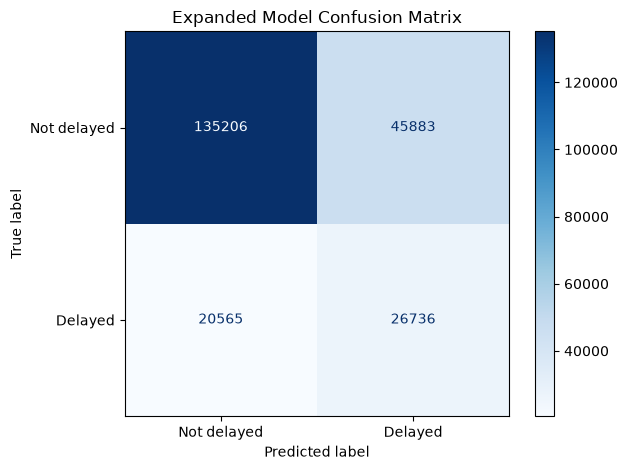

In [93]:
import os 

#Compare the actual test outcomes with the expanded model
expanded_confusion_results = confusion_matrix(
    y_test_expanded,
    y_pred_expanded
)

#Create the expanded confusion matrix chart
expanded_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=expanded_confusion_results,
    display_labels=["Not delayed", "Delayed"]
)


expanded_matrix_display.plot(cmap="Blues", values_format="d")
plt.title("Expanded Model Confusion Matrix")
plt.tight_layout()


expanded_confusion_path = os.path.expandvars(
    r"%USERPROFILE%\OneDrive\Documents\Flight Delay Prediction Model\visuals\expanded_confusion_matrix.png"
)

plt.savefig(expanded_confusion_path, dpi=300, bbox_inches="tight")
plt.show()


Compared with the baseline model, the expanded model produced **10,572 fewer false delay warnings** and detected **829 additional delays**. Therefore, the additional calendar, distance, and numerical weather features improved both precision and recall.

## 6. Select Final Model

The expanded model performed better than the baseline model across accuracy, precision, recall, and F1-score. It is therefore selected as the final model.

## 7. Interpret Final Model

### Expanded Model Feature Importance


In [94]:
#encoded feature names from the expanded preprocessing pipeline
expanded_encoded_names = (
    expanded_model.named_steps["preprocessor"].get_feature_names_out()
)

# importance score for every encoded feature
expanded_importance_scores = (
    expanded_model.named_steps["classifier"].feature_importances_
)

# Store the encoded names and scores in dataframe
expanded_encoded_importance = pd.DataFrame({
    "ENCODED_FEATURE": expanded_encoded_names,
    "IMPORTANCE": expanded_importance_scores
})

# Identify original column behind each encoded feature
def find_expanded_original_feature(encoded_name):
    for feature in expanded_categorical_features:
        if encoded_name.startswith(f"categorical__{feature}_"):
            return feature

    # Remove  pipeline prefix from numerical columns
    return encoded_name.replace("numeric__", "")

# Add  original column name
expanded_encoded_importance["ORIGINAL_FEATURE"] = (
    expanded_encoded_importance["ENCODED_FEATURE"]
    .apply(find_expanded_original_feature)
)

# Combine importance scores belonging to the same original column
final_feature_importance = (
    expanded_encoded_importance
    .groupby("ORIGINAL_FEATURE")["IMPORTANCE"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(final_feature_importance)

,ORIGINAL_FEATURE,IMPORTANCE
0,WEATHER_CONDITION,0.208856
1,DEPARTURE_HOUR,0.150431
2,VISIBILITY,0.132537
3,WINDSPEED,0.087335
4,TEMPERATURE,0.084208
5,ORIGIN,0.082439
6,PRECIPITATION,0.064760
7,AIRLINE,0.055802
8,DESTINATION,0.045813
9,DAY_OF_WEEK,0.044191


#### Final Feature Importance Results

`WEATHER_CONDITION` was the most important individual feature at **20.89%**, followed by `DEPARTURE_HOUR` at **15.04%** and `VISIBILITY` at **13.25%**.

Together, the weather-related features accounted for approximately **57.77%** of the model's total importance. This indicates that the expanded model relied heavily on weather information, while departure timing, origin, airline, destination, and calendar features also contributed.

### Final Feature Importance Chart

The chart ranks the original input columns by how strongly they influenced the expanded Random Forest's predictions.

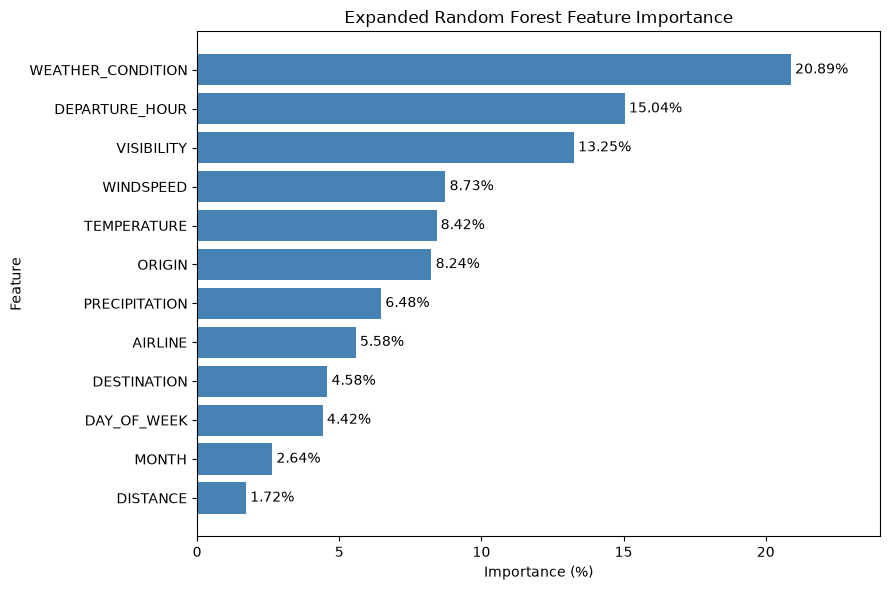

In [95]:
# Convert the importance scores to percentages
importance_percent = final_feature_importance["IMPORTANCE"] * 100

# Create the horizontal bar chart
plt.figure(figsize=(9, 6))
bars = plt.barh(
    final_feature_importance["ORIGINAL_FEATURE"],
    importance_percent,
    color="steelblue"
)

# Place the most important feature at the top
plt.gca().invert_yaxis()

# Format the chart
plt.title("Expanded Random Forest Feature Importance")
plt.xlabel("Importance (%)")
plt.ylabel("Feature")
plt.bar_label(bars, fmt="%.2f%%", padding=3)
plt.margins(x=0.15)
plt.tight_layout()

plt.savefig(
    os.path.expandvars(
        r"%USERPROFILE%\OneDrive\Documents\Flight Delay Prediction Model\visuals\feature_importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Model Assessment and Limitations
The expanded Random Forest achieved 70.91% accuracy, 36.82% precision, 56.52% recall, and a 44.59% F1-score. Although its accuracy remained below the 79.29% majority-class baseline, the baseline detected no delayed flights, while the model identified 56.52% of actual delays.

Performance improved across all metrics after adding calendar, distance, and weather features, indicating that these variables contain useful delay-risk signals. However, the model's limited precision means many predicted delays were false alarms, so it is not reliable enough for operational decision-making.

The results apply only to flights departing from 20 major US airports between January and April 2025. Future development could include hourly weather forecasts, destination weather, airport congestion, inbound-aircraft status, and a longer historical period.

## 8. Build the Delay-Risk Predictor

The model produces a delay-risk score between 0 and 1. For this exploratory tool, scores below 0.40 are classified as Low risk, scores from 0.40 to below 0.60 as Medium risk, and scores of 0.60 or higher as High risk. These categories describe relative model risk and are not guaranteed probabilities.

Note: These scores support exploratory comparison and should not be interpreted as guaranteed delay probabilities.

In [96]:
# Create a function that predicts the delay-risk level for one flight
def predict_delay_risk(
    airline,
    origin,
    destination,
    departure_hour,
    weather_condition,
    month,
    day_of_week,
    distance,
    temperature,
    visibility,
    windspeed,
    precipitation
):
    # Store the flight information as a dataframe
    flight = pd.DataFrame({
        "AIRLINE": [airline.upper()],
        "ORIGIN": [origin.upper()],
        "DESTINATION": [destination.upper()],
        "DEPARTURE_HOUR": [departure_hour],
        "MONTH": [month],
        "DAY_OF_WEEK": [day_of_week],
        "DISTANCE": [distance],
        "TEMPERATURE": [temperature],
        "VISIBILITY": [visibility],
        "WINDSPEED": [windspeed],
        "PRECIPITATION": [precipitation],
        "WEATHER_CONDITION": [weather_condition]
    })

    # Get the expanded models score for a delayed flight
    risk_score = expanded_model.predict_proba(flight)[0, 1]

    # Convert the model score into a simple risk category
    if risk_score < 0.40:
        risk_level = "Low delay risk"
    elif risk_score < 0.60:
        risk_level = "Medium delay risk"
    else:
        risk_level = "High delay risk"

    # Return both the risk category and model score
    return f"{risk_level} (model score: {risk_score:.1%})"

### Test Example Flights

The predictor is tested on three hypothetical flights with different routes, departure times, and weather conditions.

In [97]:
# Example 1: early flight with no reported weather condition
example_1 = predict_delay_risk(
    airline="DL",
    origin="SLC",
    destination="DEN",
    departure_hour=6,
    weather_condition="No reported condition",
    month=1,
    day_of_week=2,
    distance=391,
    temperature=35,
    visibility=10,
    windspeed=4,
    precipitation=0
)

# Example 2: afternoon flight with rain
example_2 = predict_delay_risk(
    airline="AA",
    origin="DFW",
    destination="ORD",
    departure_hour=14,
    weather_condition="Rain",
    month=3,
    day_of_week=3,
    distance=802,
    temperature=55,
    visibility=6,
    windspeed=12,
    precipitation=0.20
)

# Example 3: evening flight with rain and thunder
example_3 = predict_delay_risk(
    airline="OH",
    origin="DCA",
    destination="CLT",
    departure_hour=19,
    weather_condition="Rain + Thunder",
    month=4,
    day_of_week=5,
    distance=331,
    temperature=60,
    visibility=3,
    windspeed=18,
    precipitation=1.00
)

# Display the three prediction results
print("Example 1:", example_1)
print("Example 2:", example_2)
print("Example 3:", example_3)

Example 1: Low delay risk (model score: 30.7%)
Example 2: High delay risk (model score: 61.6%)
Example 3: High delay risk (model score: 73.9%)


#### Predictor Test Results

- **Example 1:** Low delay risk with a 30.7% model score.
- **Example 2:** High delay risk with a 61.6% model score.
- **Example 3:** High delay risk with a 73.9% model score.

The hypothetical scenarios demonstrate how the model converts flight and weather information into relative risk categories. The model assigned higher risk scores to the later flights with more adverse weather conditions. These scores are exploratory risk indicators rather than guaranteed delay probabilities.